In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import numpy as np
import seaborn as sns
from scipy import stats

!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importation des données

In [5]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_URL = (
    "https://raw.githubusercontent.com/OpenExoplanetCatalogue/"
    "oec_tables/master/comma_separated/open_exoplanet_catalogue.txt"
)

df = pd.read_csv(CSV_URL, comment='#')

# On renomme les colonnes pour la lisibilité
COLS = [
    "name", "binary_flag", "mass", "radius", "period", "semi_major_axis",
    "eccentricity", "periastron", "longitude", "ascending_node",
    "inclination", "surface_temp", "age", "discovery_method",
    "discovery_year", "last_updated", "ra_string", "dec_string",
    "distance_pc", "host_star_mass", "host_star_radius",
    "host_star_metallicity", "host_star_temp", "host_star_age",
    "list_flag"
]

print(f"Nombre de planètes chargées : {len(df)}")
print(f"\nColonnes disponibles :\n{df.dtypes}")

Nombre de planètes chargées : 5414

Colonnes disponibles :
name                      object
binaryflag                 int64
mass                     float64
radius                   float64
period                   float64
semimajoraxis            float64
eccentricity             float64
periastron               float64
longitude                float64
ascendingnode            float64
inclination              float64
temperature              float64
age                      float64
discoverymethod           object
discoveryyear            float64
lastupdate                object
system_rightascension     object
system_declination        object
system_distance          float64
hoststar_mass            float64
hoststar_radius          float64
hoststar_metallicity     float64
hoststar_temperature     float64
hoststar_age             float64
list                      object
dtype: object


# Acte III : Biais de détection

Dans l'Acte II, nous avons vu que les clusters C0 et C2 étaient dominés par le transit, tandis que C1 l'était par la vitesse radiale. Ce n'est pas une coïncidence. Ces deux méthodes ne détectent pas les mêmes types de planètes. Dans cet acte, nous allons explorer ces biais et comprendre comment ils façonnent notre vision du cosmos.

## Distribution des méthodes de détection

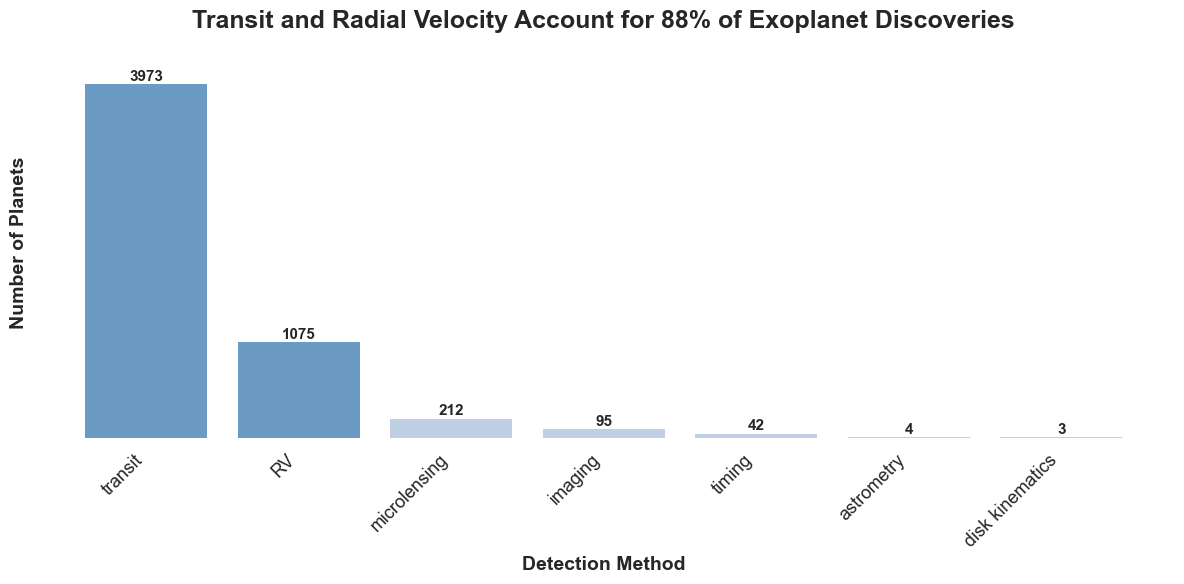

In [8]:
import matplotlib.pyplot as plt

method_counts = df['discoverymethod'].value_counts()

# Défini les couleurs
def get_color(method):
    method_lower = str(method).lower()
    if 'transit' in method_lower or 'rv' in method_lower or 'radial' in method_lower:
        return 'steelblue'
    return 'lightsteelblue'

colors = [get_color(m) for m in method_counts.index]

plt.figure(figsize=(12,6))

# Crée le graphique à barres sans les bordure
bars = plt.bar(method_counts.index,
               method_counts.values,
               color=colors,
               edgecolor='none',
               alpha=0.8)

# Ajoute les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Detection Method', fontsize=14, fontweight='bold')
plt.ylabel('Number of Planets', fontsize=14, fontweight='bold')

plt.title('Transit and Radial Velocity Account for 88% of Exoplanet Discoveries',
          fontsize=18, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=13)

plt.grid(False)

plt.yticks([])

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.ylim(0, max(method_counts.values) * 1.1)

plt.tight_layout()
plt.show()

Deux méthodes dominent très largement le recensement des exoplanètes. Le transit (Kepler) et la vitesse radiale représentent à elles seules près de 88 % des découvertes. L'imagerie directe, la microlentille et les autres méthodes restent plutôt marginales.

### Evolution temporelle des découvertes

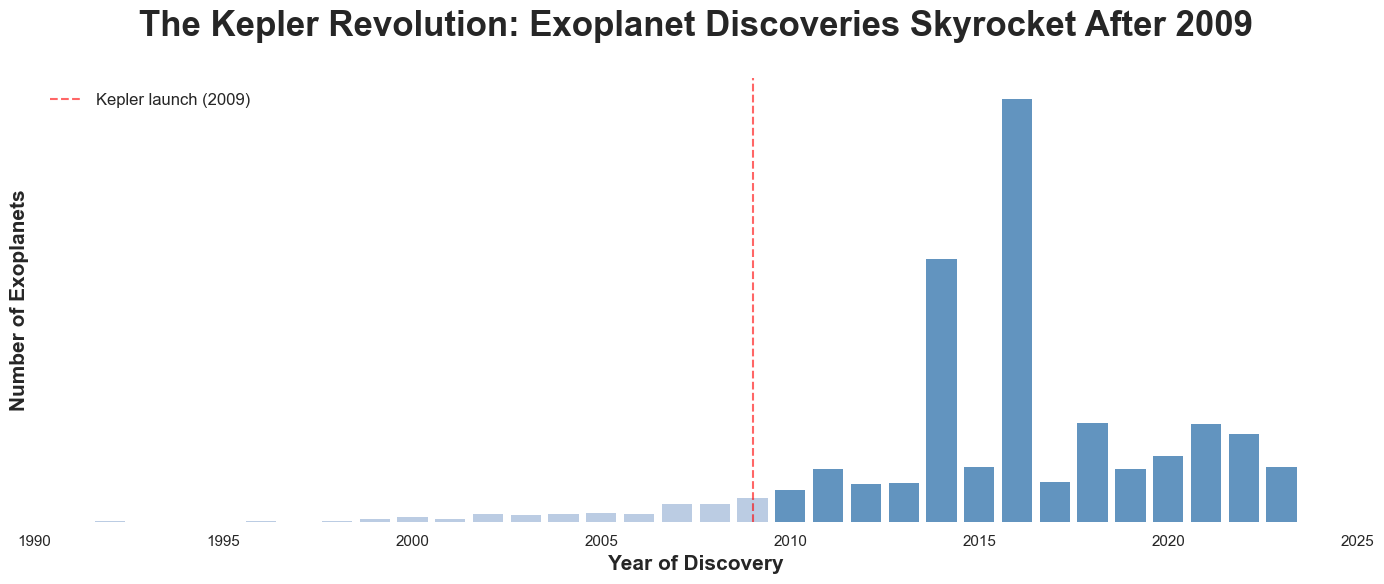

In [26]:
# On va garder juste les lignes avec une méthode de découverte
df_clean = df.dropna(subset=["discoverymethod"])

# Groupe par année
discovery_counts = (
    df_clean
    .groupby("discoveryyear")
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14,6))

# Barres avec dégradé de couleur (plus foncé après 2010 pour montrer le pic)
colors = ['lightsteelblue' if year < 2010 else 'steelblue' for year in discovery_counts["discoveryyear"]]

plt.bar(
    discovery_counts["discoveryyear"],
    discovery_counts["count"],
    width=0.8,
    color=colors,
    edgecolor='none',
    alpha=0.85
)

# Ajoute une ligne verticale pour marquer le début de Kepler
plt.axvline(x=2009, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Kepler launch (2009)')

plt.xlabel("Year of Discovery", fontsize=15, fontweight='bold')
plt.ylabel("Number of Exoplanets", fontsize=15, fontweight='bold')
plt.title("The Kepler Revolution: Exoplanet Discoveries Skyrocket After 2009",
          fontsize=25, fontweight='bold', pad=30)

plt.ylim(bottom=0)
plt.xlim(1990, 2025)

plt.grid(False)

plt.yticks([])

# Supprime tous les cadres
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.legend(loc='upper left', fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

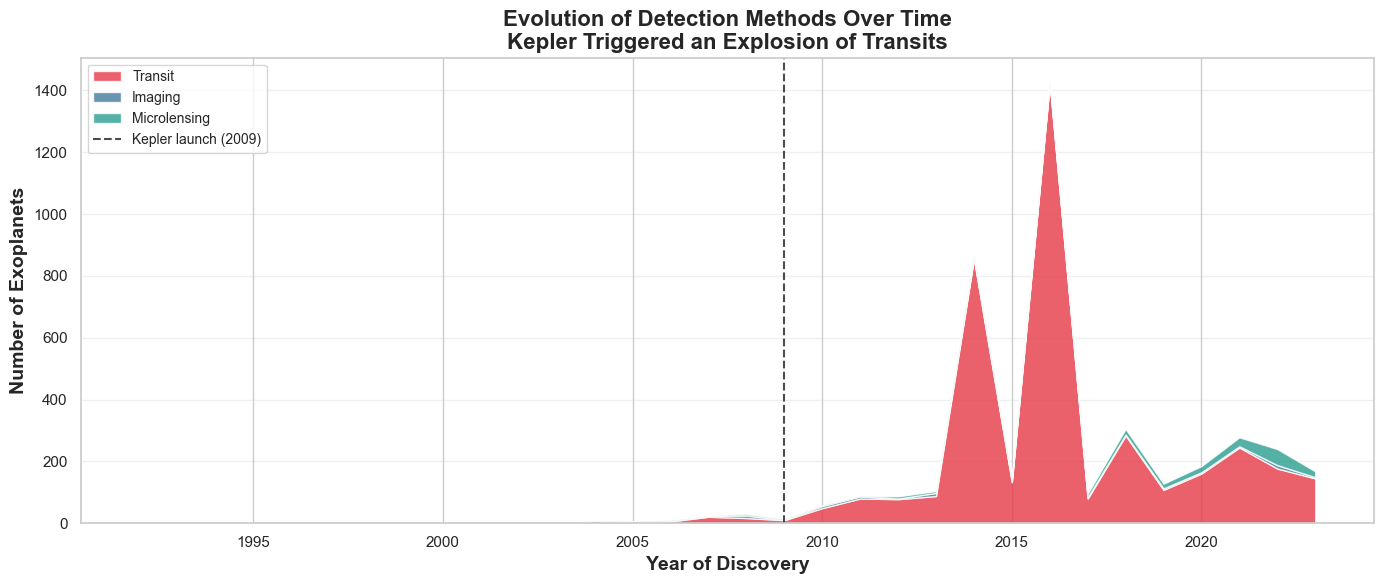

In [25]:
# Préparer les données
df_temp = df.dropna(subset=['discoveryyear', 'discoverymethod'])
df_temp = df_temp[df_temp['discoveryyear'] > 1990]

# Compter par année et méthode
stacked_data = df_temp.groupby(['discoveryyear', 'discoverymethod']).size().unstack(fill_value=0)

# Garder les principales méthodes
main_methods = ['transit', 'rv', 'radial velocity', 'imaging', 'microlensing']
stacked_data = stacked_data[[m for m in main_methods if m in stacked_data.columns]]

plt.figure(figsize=(14,6))
plt.stackplot(stacked_data.index, stacked_data.T.values,
              labels=[m.capitalize() for m in stacked_data.columns],
              colors=['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#984ea3'],
              alpha=0.8)

plt.axvline(x=2009, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label='Kepler launch (2009)')

plt.xlabel('Year of Discovery', fontsize=14, fontweight='bold')
plt.ylabel('Number of Exoplanets', fontsize=14, fontweight='bold')
plt.title('Evolution of Detection Methods Over Time\nKepler Triggered an Explosion of Transits',
          fontsize=16, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

L'évolution temporelle raconte une histoire. Avant 2009, la vitesse radiale régnait en maître. Mais le lancement de Kepler a tout changé. À partir de 2010, les transits explosent et deviennent la méthode dominante. Aujourd'hui, la majorité des exoplanètes connues viennent de Kepler et de sa successeuse TESS.

## Distribution des masses par méthode (boxplot)

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_9632\3598490630.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='discoverymethod', y='mass', palette='Set2')


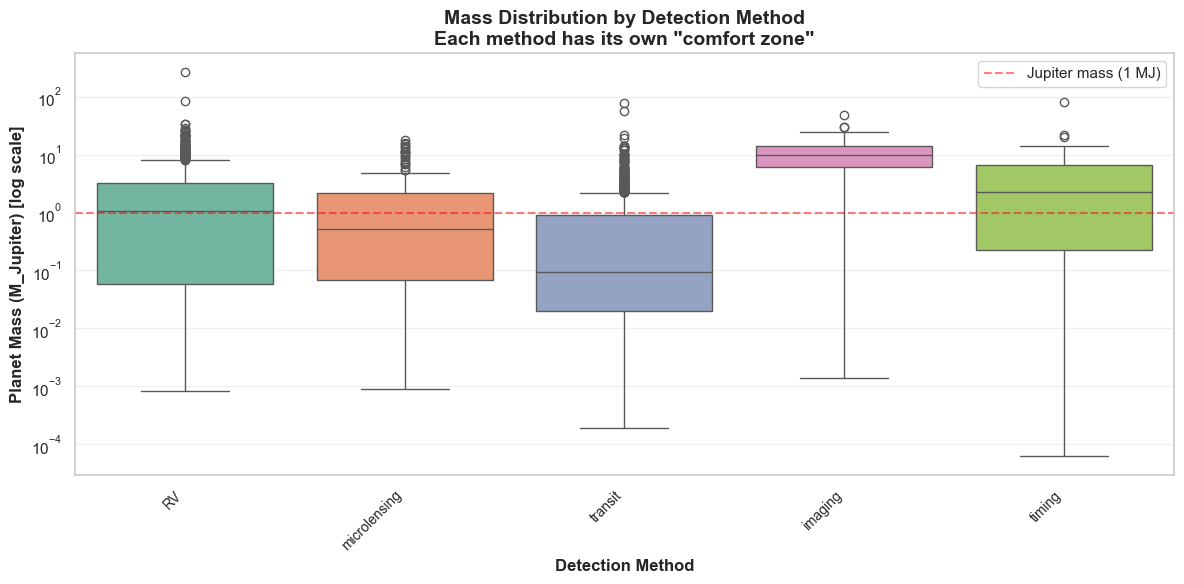

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparer les données
df_box = df.dropna(subset=['mass', 'discoverymethod'])
# Garder les méthodes avec au moins 10 planètes
top_methods = df_box['discoverymethod'].value_counts()[df_box['discoverymethod'].value_counts() >= 10].index
df_box = df_box[df_box['discoverymethod'].isin(top_methods)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_box, x='discoverymethod', y='mass', palette='Set2')

plt.yscale('log')
plt.xlabel('Detection Method', fontsize=12, fontweight='bold')
plt.ylabel('Planet Mass (M_Jupiter) [log scale]', fontsize=12, fontweight='bold')
plt.title('Mass Distribution by Detection Method\nEach method has its own "comfort zone"',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

# Ajouter une ligne de référence pour Jupiter (1 MJ)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Jupiter mass (1 MJ)')
plt.legend()

plt.tight_layout()
plt.show()

Les différences entre méthodes sont nettes. Le transit détecte surtout des planètes de faible masse, tandis que la vitesse radiale couvre une gamme plus large et plus massive. L’imagerie est fortement biaisée vers des planètes très massives. Chaque méthode a ainsi sa "zone de confort", révélant des populations différentes et introduisant des biais d’observation.

## Retour sur la loi de Kepler

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\1627671359.py:27: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.scatterplot(


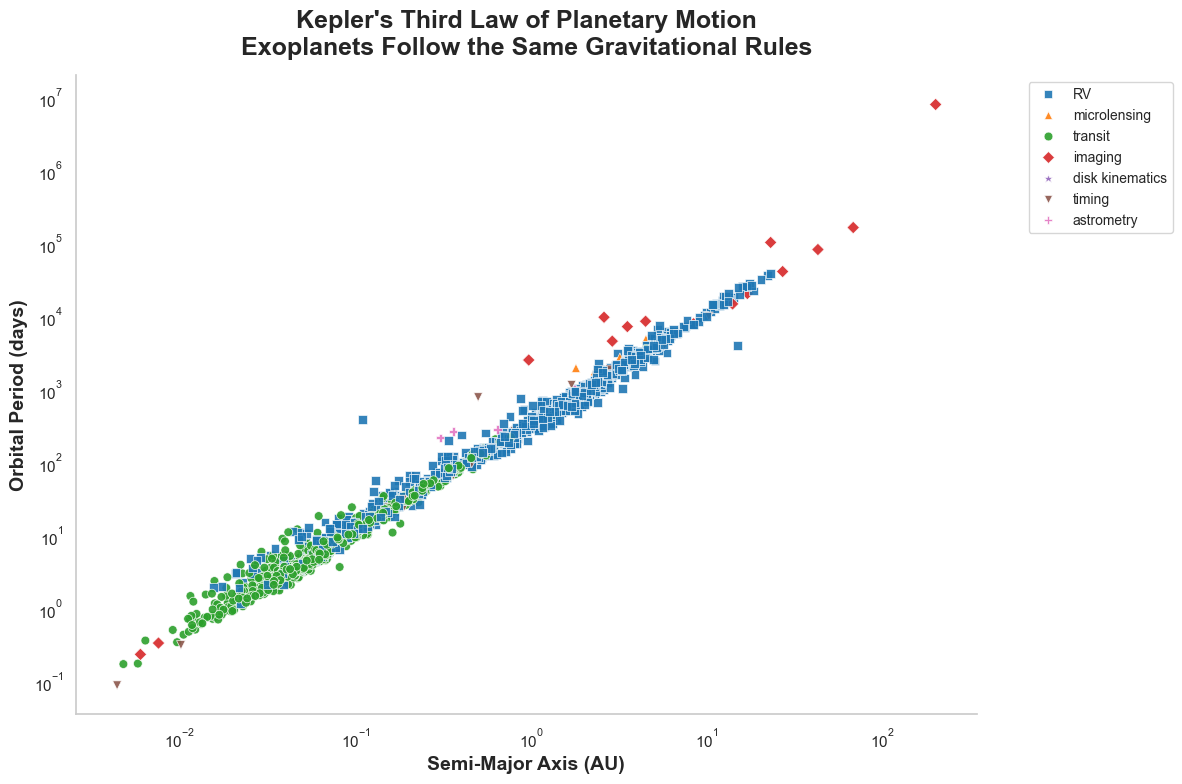

In [42]:
plt.figure(figsize=(12,8))

unique_methods = df["discovery_method"].unique()

# Mapping formes
markers = {
    "transit": "o",
    "rv": "s",
    "RV": "s",  # Ajout pour la casse majuscule
    "radial velocity": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P",
    "disk kinematics": "*",
    "Disk Kinematics": "*",  # Au cas où
}

# Palette avec du contraste
palette = sns.color_palette("tab10", n_colors=len(unique_methods))

sns.scatterplot(
    data=df,
    x="semi_major_axis",
    y="period",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.9,
    s=40
)


plt.xscale("log")
plt.yscale("log")

plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Orbital Period (days)", fontsize=14, fontweight='bold')
plt.title("Kepler's Third Law of Planetary Motion\nExoplanets Follow the Same Gravitational Rules",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.tick_params(axis='both', which='major', labelsize=11)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

Les planètes que nous détectons en majorité sont celles qui ont des périodes courtes (transit) ou des masses élevées (RV). Si nous pouvions observer toutes les planètes, verrions-nous encore cette relation ? Peut-être que notre échantillon est biaisé par les limites instrumentales.

## Hot Jupiters

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_18772\257044576.py:7: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.scatterplot(


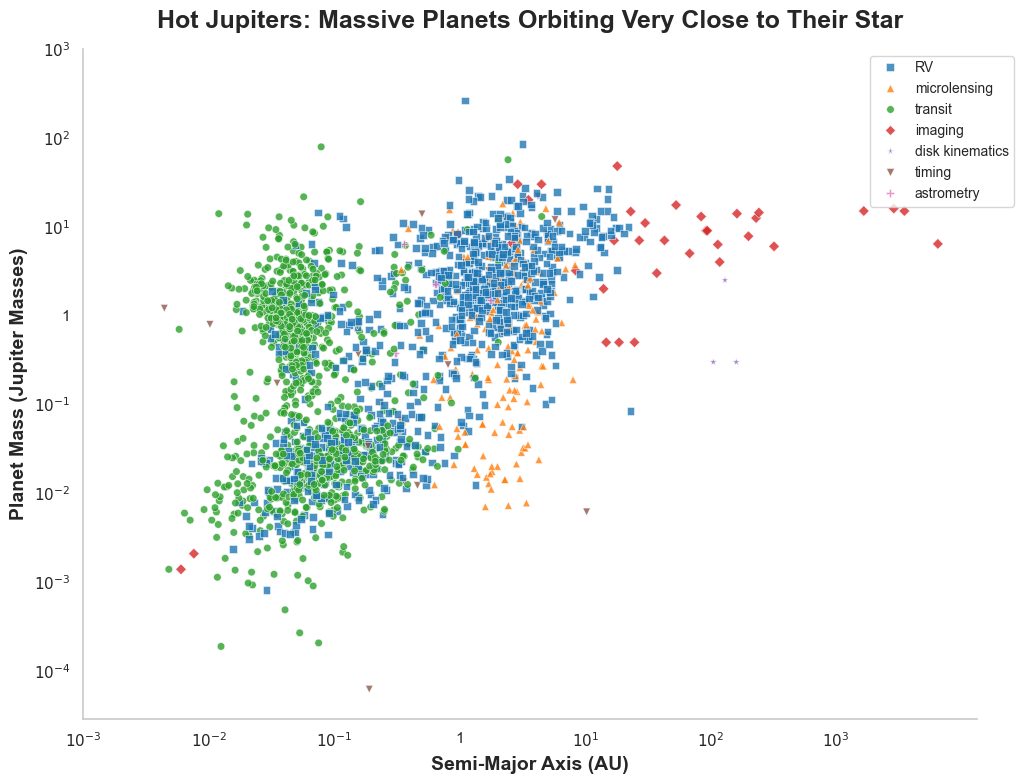

In [59]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="semi_major_axis",
    y="mass",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=30
)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels([r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

plt.xlabel("Semi-Major Axis (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Planet Mass (Jupiter Masses)", fontsize=14, fontweight='bold')
plt.title("Hot Jupiters: Massive Planets Orbiting Very Close to Their Star",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

Souvenez-vous des Hot Jupiters vus dans l'Acte I. Pourquoi en avons-nous détecté autant ? Parce qu'ils sont idéaux pour le transit. Une grosse planète qui passe devant une petite étoile, ça produit un signal énorme. Ce n'est pas forcément qu'ils sont fréquents. C'est surtout qu'ils sont faciles à voir. C'est l'exemple parfait d'un biais de détection.

Ces biais nous rappellent que notre carte des exoplanètes est encore partielle. Pour prendre conscience de l'étendue de ce qu'il nous reste à découvrir, plongeons maintenant dans une visualisation immersive de la Voie lactée.